In [83]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [84]:
df = pd.read_csv('../data/ecommerce_cleaned.csv')

In [85]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [86]:
# Feature Engineering

df["Year"] = df["InvoiceDate"].dt.year
df["Month"] = df["InvoiceDate"].dt.month
df["Day"] = df["InvoiceDate"].dt.day

In [87]:
df.head() 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,1


In [ ]:
# total Revenue
total_revenue = df["Revenue"].sum()

Total Revenue: 8911407.904


In [ ]:
# Monthly Revenue 
monthly_revenue = df.groupby(df["Month"], as_index = False)["Revenue"].sum()

    Month      Revenue
0       1   569445.040
1       2   447137.350
2       3   595500.760
3       4   469200.361
4       5   678594.560
5       6   661213.690
6       7   600091.011
7       8   645343.900
8       9   952838.382
9      10  1039318.790
10     11  1161817.380
11     12  1090906.680


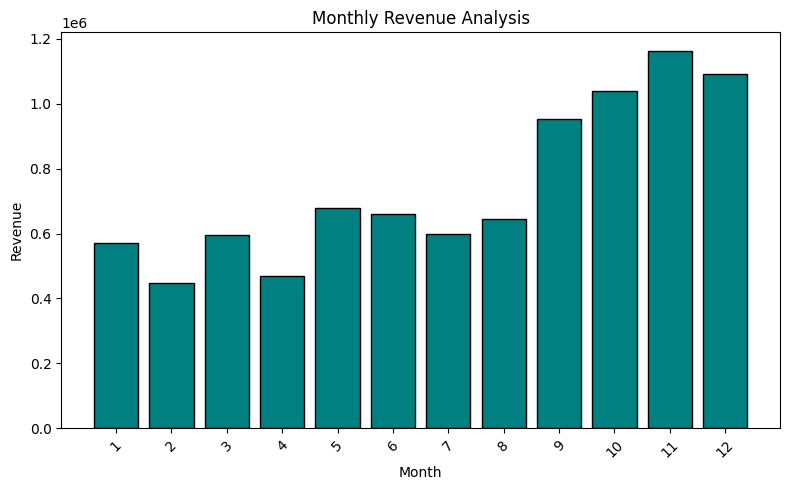

In [90]:
plt.figure(figsize = (8,5)),
plt.bar(monthly_revenue["Month"], monthly_revenue["Revenue"], color = "teal", edgecolor = "black")
plt.title("Monthly Revenue Analysis")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(monthly_revenue["Month"], rotation = 45)
plt.tight_layout()
plt.savefig("../images/monthly_revenue.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Top Selloing Products
top_selling_products = df.groupby("Description", as_index=False)["Revenue"].sum().sort_values(by="Revenue", ascending=False).head(10)

                             Description    Revenue
2319         PAPER CRAFT , LITTLE BIRDIE  168469.60
2767            REGENCY CAKESTAND 3 TIER  142592.95
3698  WHITE HANGING HEART T-LIGHT HOLDER  100448.15
1762             JUMBO BAG RED RETROSPOT   85220.78
1992      MEDIUM CERAMIC TOP STORAGE JAR   81416.73
2611                             POSTAGE   77803.96
2345                       PARTY BUNTING   68844.33
216        ASSORTED COLOUR BIRD ORNAMENT   56580.34
2130                              Manual   53779.93
2656                  RABBIT NIGHT LIGHT   51346.20


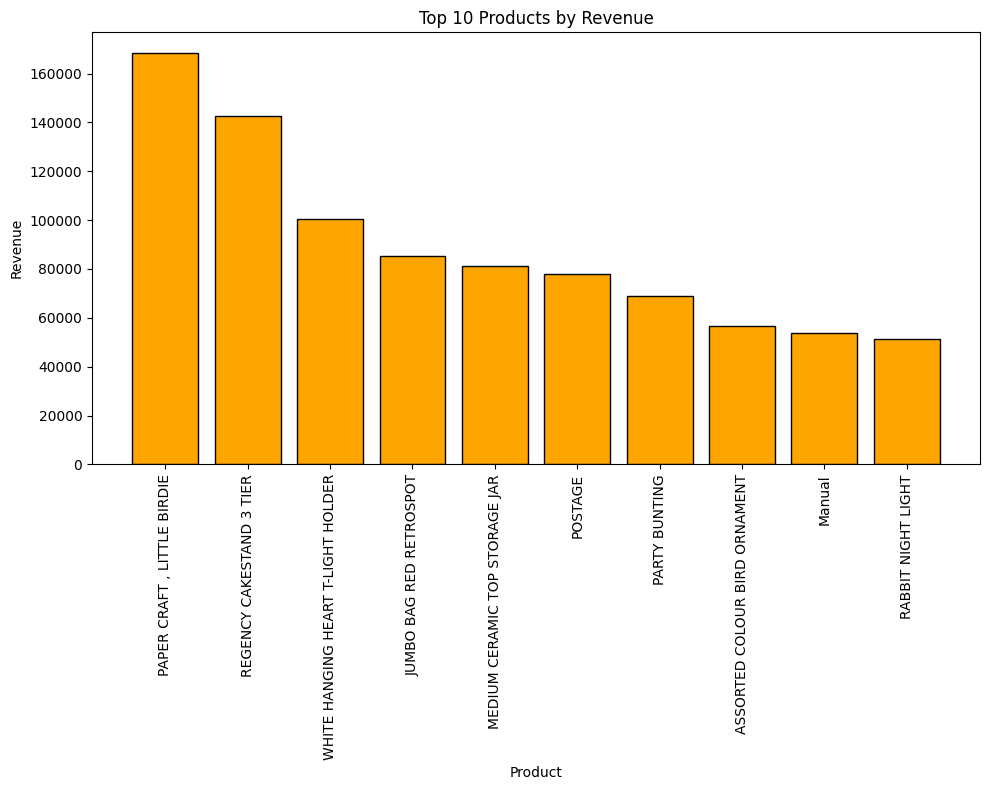

In [103]:
plt.figure(figsize = (10,8))
plt.bar(top_selling_products["Description"], top_selling_products["Revenue"], color = "orange", edgecolor = "black")
plt.xlabel("Product")
plt.ylabel("Revenue")
plt.xticks(rotation = 90)
plt.title("Top 10 Products by Revenue")
plt.tight_layout()
plt.savefig("../images/top_selling_products.png", dpi=300, bbox_inches="tight")
plt.show()

In [93]:
# Revenue by Country
country_sales = df.groupby("Country", as_index = False)["Revenue"].sum().head(10)

Text(0.5, 1.0, 'Top 10 Countries by Revenue')

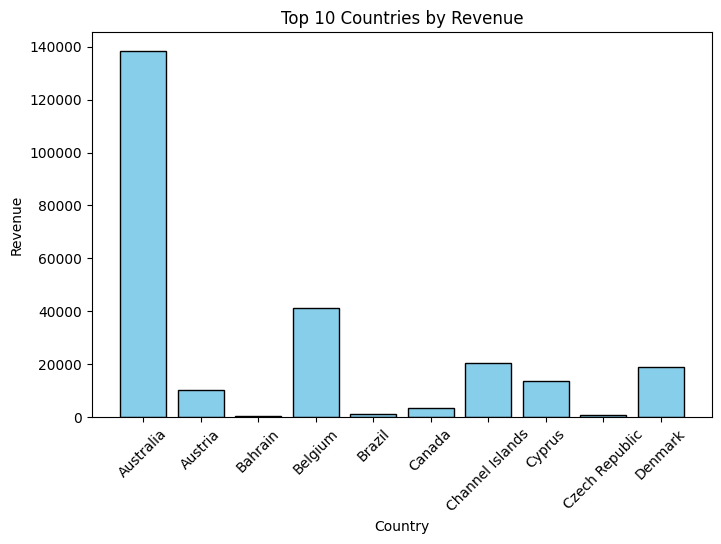

In [94]:
plt.figure(figsize =(8,5))
plt.bar(country_sales["Country"], country_sales["Revenue"], color = "skyblue", edgecolor = "black")
plt.xlabel("Country")
plt.ylabel("Revenue")
plt.xticks(rotation = 45)
plt.title("Top 10 Countries by Revenue")   

In [95]:
# Analysis of Customer Segmentation and Behavior
df["CustomerID"].nunique()

4339

In [ ]:
orders_per_customer = df.groupby("CustomerID", as_index = False)["InvoiceNo"].nunique()

   CustomerID  InvoiceNo
0     12346.0          1
1     12347.0          7
2     12348.0          4
3     12349.0          1
4     12350.0          1
